In [ ]:
import numpy as np
import json
from matplotlib import pyplot as plt
from paretoset import paretoset
import pandas as pd

import matplotlib
matplotlib.rcParams['figure.dpi'] = 300

In [19]:
def load_experimental_data(path, min_recall):
    # Load the relevant JSON files
    with open(path, "r") as f:
        vanilla_lsh = json.load(f)
        
    sizes_mb = np.array([x['size_mb'] for x in vanilla_lsh if x['recall'] > min_recall])
    times = [x['time_ms'] for x in vanilla_lsh  if x['recall'] > min_recall]
    recalls = [x['recall'] for x in vanilla_lsh if x['recall'] > min_recall]
    
    
    qps = np.array([1000 / x for x in times])
    compound_measure = sizes_mb / qps

    df = pd.DataFrame({
        "recalls": recalls,
        "compound_measure": compound_measure,
    })
    
    mask = paretoset(df, sense=["max", "min"])
    
    df = pd.DataFrame({
        "compound_measure": compound_measure,
        "recalls": recalls,
        "sizes_mb": sizes_mb,
        "times_ms": times,
        "qps": qps
    })
    
    frontier = df[mask].sort_values("recalls", ascending=True).reset_index(drop=True)
    return frontier

In [20]:
df_vanilla = load_experimental_data("mf_dino2/vanilla_lsh.json", 0.4)
df_mtq = load_experimental_data("mf_dino2/mtq_lsh.json", 0.4)
df_cqu_lsh = load_experimental_data("mf_dino2/cqu_lsh.json", 0.4)


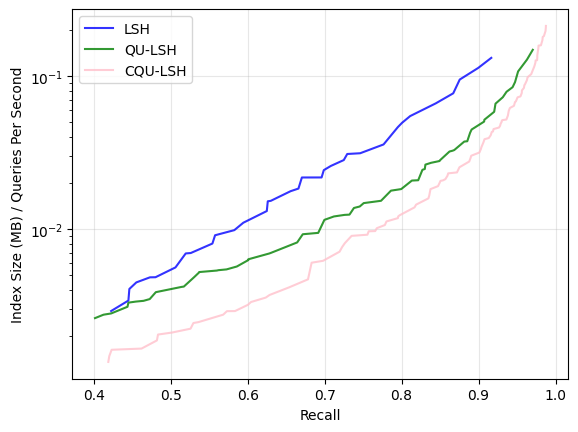

In [21]:
plt.plot(df_vanilla['recalls'], df_vanilla["compound_measure"], color="blue", alpha=0.8, label="LSH")
plt.plot(df_mtq['recalls'], df_mtq["compound_measure"], color="green", alpha=0.8, label="QU-LSH")
plt.plot(df_cqu_lsh["recalls"], df_cqu_lsh["compound_measure"], color="pink", alpha=0.8, label="CQU-LSH", linewidth=1.5)


plt.yscale("log")
plt.xlabel("Recall")
plt.ylabel("Index Size (MB) / Queries Per Second")

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [22]:
def load_experimental_data_recall_index_size(path, min_recall):
    # Load the relevant JSON files
    with open(path, "r") as f:
        vanilla_lsh = json.load(f)
        
    sizes_mb = np.array([x['size_mb'] for x in vanilla_lsh if x['recall'] > min_recall])
    times = [x['time_ms'] for x in vanilla_lsh  if x['recall'] > min_recall]
    recalls = [x['recall'] for x in vanilla_lsh if x['recall'] > min_recall]
    


    df = pd.DataFrame({
        "recalls": recalls,
        "size_mb": sizes_mb,
    })
    
    mask = paretoset(df, sense=["max", "min"])
    
    frontier = df[mask].sort_values("recalls", ascending=True).reset_index(drop=True)
    return frontier

In [23]:
df_vanilla = load_experimental_data_recall_index_size("mf_dino2/vanilla_lsh.json", 0.4)
df_mtq = load_experimental_data_recall_index_size("mf_dino2/mtq_lsh.json", 0.4)
df_cqu_lsh = load_experimental_data_recall_index_size("mf_dino2/cqu_lsh.json", 0.4)


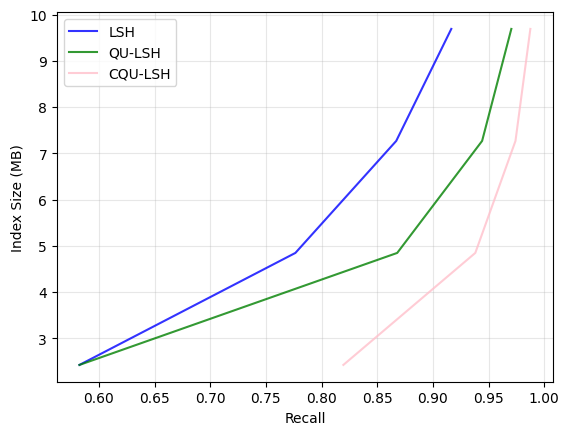

In [24]:
plt.plot(df_vanilla['recalls'], df_vanilla["size_mb"], color="blue", alpha=0.8, label="LSH")
plt.plot(df_mtq['recalls'], df_mtq["size_mb"], color="green", alpha=0.8, label="QU-LSH")
plt.plot(df_cqu_lsh['recalls'], df_cqu_lsh["size_mb"], color="pink", alpha=0.8, label="CQU-LSH")


plt.xlabel("Recall")
plt.ylabel("Index Size (MB)")
# plt.yscale("log")
# plt.title("Parteo Optimal Configurations: Size vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [25]:
def load_experimental_data_qps(path, min_recall):
    # Load the relevant JSON files
    with open(path, "r") as f:
        vanilla_lsh = json.load(f)

        
    times = [x['time_ms'] for x in vanilla_lsh if x['recall'] > min_recall]
    recalls = [x['recall'] for x in vanilla_lsh if x['recall'] > min_recall]

    df = pd.DataFrame({
        "recalls": recalls,
        "times_ms": times,
    })
    
    mask = paretoset(df, sense=["max", "min"])
    
    df = pd.DataFrame({
        "recalls": recalls,
        "times_ms": times,
        "qps": [1000 / x for x in times]
    })
    
    frontier = df[mask].sort_values("recalls", ascending=True).reset_index(drop=True)
    return frontier

In [26]:
df_vanilla = load_experimental_data_qps("mf_dino2/vanilla_lsh.json", 0.4)
df_mtq = load_experimental_data_qps("mf_dino2/mtq_lsh.json", 0.4)
df_cqu_lsh = load_experimental_data_qps("mf_dino2/cqu_lsh.json", 0.4)


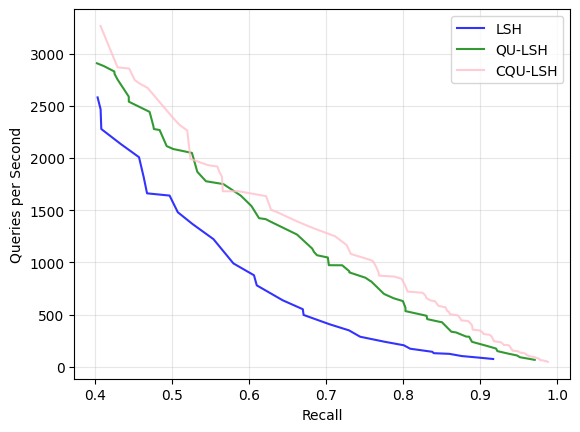

In [ ]:
plt.plot(df_vanilla["recalls"], df_vanilla["qps"], color="blue", alpha=0.8, label="LSH", linewidth=1.5)
plt.plot(df_mtq["recalls"], df_mtq["qps"], color="green", alpha=0.8, label="QU-LSH", linewidth=1.5)
plt.plot(df_cqu_lsh["recalls"], df_cqu_lsh["qps"], color="pink", alpha=0.8, label="CQU-LSH", linewidth=1.5)


plt.yscale("log")
# plt.xscale("log")
plt.xlabel("Recall")
plt.ylabel("Queries per Second")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Is there a difference in the number of probes / bits between algs?

In [28]:
def load_experimental_data_qps_with_config_info(path, min_recall):
    # Load the relevant JSON files
    with open(path, "r") as f:
        vanilla_lsh = json.load(f)

        
    times = [x['time_ms'] for x in vanilla_lsh if x['recall'] > min_recall]
    recalls = [x['recall'] for x in vanilla_lsh if x['recall'] > min_recall]
    bits = [x['num_hash_bits'] for x in vanilla_lsh if x['recall'] > min_recall]
    probes = [x['probes_per_table'] for x in vanilla_lsh if x['recall'] > min_recall]


    df = pd.DataFrame({
        "recalls": recalls,
        "times_ms": times,
    })
    
    mask = paretoset(df, sense=["max", "min"])
    
    df = pd.DataFrame({
        "recalls": recalls,
        "times_ms": times,
        "qps": [1000 / x for x in times],
        "bits": bits,
        "probes": probes,
    })
    
    frontier = df[mask].sort_values("recalls", ascending=True).reset_index(drop=True)
    return frontier

## Build Time Graphs

In [29]:
def load_experimental_data_build(path, min_recall):
    # Load the relevant JSON files
    with open(path, "r") as f:
        vanilla_lsh = json.load(f)

        
    # times = [x['time_ms'] for x in vanilla_lsh if x['recall'] > min_recall]
    recalls = [x['recall'] for x in vanilla_lsh if x['recall'] > min_recall]
    build_times_ms = [x['build_time_ms'] for x in vanilla_lsh if x['recall'] > min_recall]


    df = pd.DataFrame({
        "recalls": recalls,
        "build_times_ms": build_times_ms,
    })
    
    mask = paretoset(df, sense=["max", "min"])
    
    df = pd.DataFrame({
        "recalls": recalls,
        "build_times_s": [x / 1000 for x in build_times_ms],
    })
    
    frontier = df[mask].sort_values("recalls", ascending=True).reset_index(drop=True)
    return frontier

In [30]:
df_vanilla = load_experimental_data_build("mf_dino2/vanilla_lsh.json", 0.4)
df_mtq = load_experimental_data_build("mf_dino2/mtq_lsh.json", 0.4)
df_cqu_lsh = load_experimental_data_build("mf_dino2/cqu_lsh.json", 0.4)


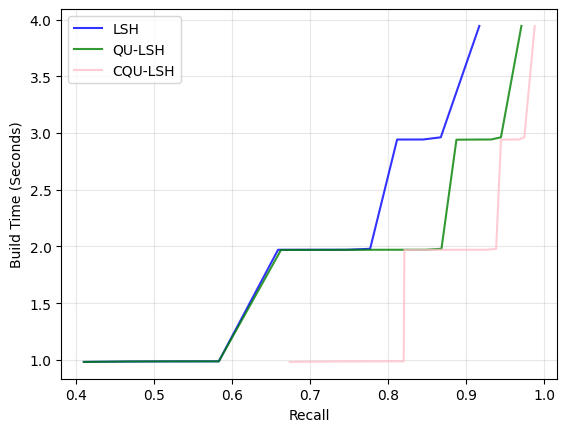

In [31]:
plt.plot(df_vanilla["recalls"], df_vanilla["build_times_s"], color="blue", alpha=0.8, label="LSH", linewidth=1.5)
plt.plot(df_mtq["recalls"], df_mtq["build_times_s"], color="green", alpha=0.8, label="QU-LSH", linewidth=1.5)
plt.plot(df_cqu_lsh["recalls"], df_cqu_lsh["build_times_s"], color="pink", alpha=0.8, label="CQU-LSH", linewidth=1.5)

plt.xlabel("Recall")
plt.ylabel("Build Time (Seconds)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Query time normalised build time

In [32]:
def load_experimental_data_build_and_query(path, min_recall):
    # Load the relevant JSON files
    with open(path, "r") as f:
        vanilla_lsh = json.load(f)

        
    times = [x['time_ms'] for x in vanilla_lsh if x['recall'] > min_recall]
    recalls = [x['recall'] for x in vanilla_lsh if x['recall'] > min_recall]
    build_times_ms = [x['build_time_ms'] for x in vanilla_lsh if x['recall'] > min_recall]
    
    
    qps = np.array([1000 / x for x in times])
    compound_measure = [build_times_ms[i] / qps[i] for i in range(len(recalls))]



    df = pd.DataFrame({
        "recalls": recalls,
        "build_efficiency": compound_measure,
    })
    
    mask = paretoset(df, sense=["max", "min"])

    
    frontier = df[mask].sort_values("recalls", ascending=True).reset_index(drop=True)
    return frontier

In [33]:
df_vanilla = load_experimental_data_build_and_query("mf_dino2/vanilla_lsh.json", 0.4)
df_mtq = load_experimental_data_build_and_query("mf_dino2/mtq_lsh.json", 0.4)
df_cqu_lsh = load_experimental_data_build_and_query("mf_dino2/cqu_lsh.json", 0.4)

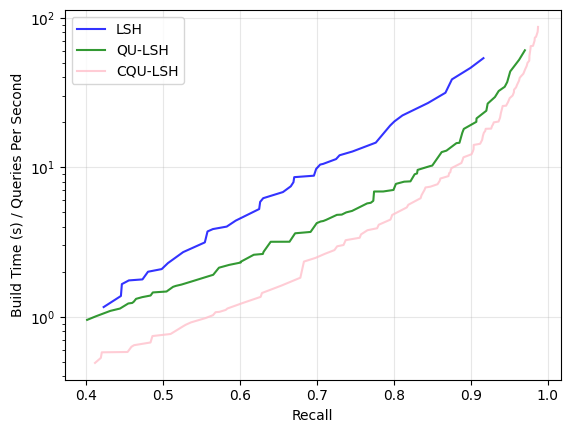

In [34]:
plt.plot(df_vanilla["recalls"], df_vanilla["build_efficiency"], color="blue", alpha=0.8, label="LSH", linewidth=1.5)
plt.plot(df_mtq["recalls"], df_mtq["build_efficiency"], color="green", alpha=0.8, label="QU-LSH", linewidth=1.5)
plt.plot(df_cqu_lsh["recalls"], df_cqu_lsh["build_efficiency"], color="pink", alpha=0.8, label="CQU-LSH", linewidth=1.5)

plt.xlabel("Recall")
plt.ylabel("Build Time (s) / Queries Per Second")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.legend()
plt.show()
